# Neural Networks with PyTorch

This notebook builds on logistic regression concepts and introduces neural networks. It covers random weight initialisation, feed-forward networks, backpropagation, the XOR problem, and multilayer perceptron classification on the Iris dataset.

## Objectives

- Explain why neural networks use random weight initialisation.
- Build a simple feed-forward neural network manually.
- Apply backpropagation to learn the XOR function.
- Train multilayer perceptrons using PyTorch built-in methods.
- Compare the performance of different hidden-layer sizes.

## Dataset

The notebook uses the XOR toy problem and the Iris dataset.


## 1. Introduction to Neural Networks

Neural networks are built from connected units that apply weighted sums and non-linear activation functions. Although each unit performs a simple calculation, networks can learn more complex patterns when multiple units are combined into layers.

A basic neuron can be described using three components:

1. Weights
2. An input function
3. An activation function

A feed-forward neural network connects these units in layers. In this notebook, sigmoid activation functions are used to extend the logistic regression ideas from the classification notebook.


# 2. Random Weight Initialisation


This section explores why neural networks normally use random initial weights instead of setting all weights to zero. Random initialisation helps break symmetry between neurons so that different neurons can learn different features.


In [275]:
import torch
from torch import nn
from torch import optim
from torch.nn import functional as F
from sklearn import model_selection
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from IPython import display

import typing
%matplotlib inline

torch.manual_seed(0)

In [276]:
## sigmoid
def sigmoid(z: torch.Tensor) -> torch.Tensor:
  ### your code here
  return 1 / (1 + torch.exp(-z))
  

In [277]:
## logistic regression class

class LogisticRegression(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        # ^weights are random this time
        self.weight = nn.Parameter(torch.randn(1, num_features), requires_grad=True)

    
    def forward(self, x):
        # ^ edit so that shape matches x (1, num_features)
        x = x.reshape(1, -1)  
        return torch.sigmoid(x @ self.weight.T)



# 3. XOR Problem


The XOR problem is revisited as an example of a pattern that cannot be solved using a single linear decision boundary.


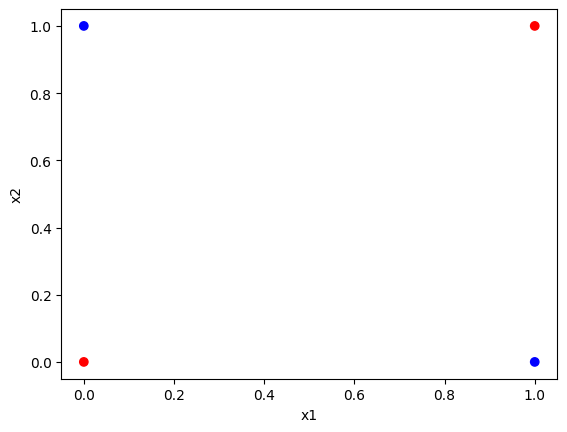

In [278]:
x1 = [0, 0, 1, 1]
x2 = [0, 1, 0, 1]
y = [0, 1, 1, 0]

c_map = ['r', 'b', 'b', 'r']
plt.scatter(x1, x2, c=c_map)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

A neural network can solve XOR by using hidden neurons to learn intermediate non-linear representations before producing the final output.


A feed-forward network is implemented to solve the XOR problem. The network has two input features, two hidden neurons, and one output neuron.

The implementation uses the earlier `LogisticRegression` unit and sigmoid activation function. The forward pass processes one sample at a time.


In [ ]:

#*NOTE - shape of x is (1, num_features); there are: 2 inputs, 2 hidden neurons, 1 output neuron 
#* a bias of 1 is added on the inputs, hidden and output neurons EACH
class NeuralNetwork(nn.Module):
    def __init__(self, num_inputs=2, num_hidden_neurons=2, num_outputs=1):
        super().__init__()
        self.hidden_layer = nn.ModuleList([LogisticRegression(num_inputs) for _ in range(num_hidden_neurons)])
        self.output_layer = nn.ModuleList([LogisticRegression(num_hidden_neurons + 1) for _ in range(num_outputs)]) # !+1 for the bias

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y_hidden = torch.ones(len(self.hidden_layer) + 1)  # !+1 for the bias term
        #*NOTE - go through each hidden neurons and calc the output
        for i, hidden_neuron in enumerate(self.hidden_layer):
            # ^ apply neuron to input x then store it
            hidden_output = hidden_neuron(x)
            y_hidden[i] = hidden_output

        # ^reshape to shape of (1, num_features + 1)
        hidden_output_bias = y_hidden.view(1, -1)
        
        # ^ calc activation function 
        output_neuron = self.output_layer[0](hidden_output_bias)
        
        return output_neuron

    def backward_pass(self, x: torch.tensor, y: torch.tensor, lr: float) -> None:
        ### your code here
        #*NOTE - go through each hidden neurons and calc the output again 
        hidden_neuron_outputs = []
        for neuron in self.hidden_layer:
            hidden_neuron_outputs.append(neuron(x))
        
        
        # ^stack outputs and add bias
        hidden_neuron_outputs = torch.stack(hidden_neuron_outputs).view(-1, 1) #^ view edit to match shape
        bias = torch.tensor([[1.0]])
        #^ cat together
        hidden_output_with_bias = torch.cat([hidden_neuron_outputs, bias], dim=0)
        
        final_output = self.output_layer[0](hidden_output_with_bias)

        #*NOTE - Step 1
        # ^ calc error
        error = final_output - y
        # ^ calc derivative of sigmoid at final output
        sigmoid_derivative_output = final_output * (1 - final_output)
        # ^ error * sigmoid deriv
        output_delta = error * sigmoid_derivative_output

        #*NOTE - Step 2
        hidden_deltas = []
        for j_neuron, hidden_neuron in enumerate(self.hidden_layer):
            # ^ weight from j neuron to k output neuron
            jk_neuron_weight = self.output_layer[0].weight[0, j_neuron]
            # ^ deriv of sigmoid at j neuron
            sigmoid_deriv_j = hidden_neuron_outputs[j_neuron] * (1 - hidden_neuron_outputs[j_neuron])
            # ^ calc delta j error
            hidden_delta = sigmoid_deriv_j * jk_neuron_weight * output_delta
            
            hidden_deltas.append(hidden_delta)

        #*NOTE - Step 3
        # ^ for each j neuron update output weights
        new_output_weights = self.output_layer[0].weight.detach().clone() # ^ edit: gets weight, detaches tensor and clones so it doesn't interfere with calculations
        for j_neuron in range(len(self.hidden_layer)):
            # ^ calc weight update
            weight_update = (lr * output_delta * hidden_output_with_bias[j_neuron]).reshape(1, 1)
            new_output_weights[0, j_neuron] = new_output_weights[0, j_neuron] - weight_update[0, 0]
        
        # ^ edit: assigns weight without in-place modification error (requires_grad is false since we are manually updating weights)
        self.output_layer[0].weight = nn.Parameter(new_output_weights, requires_grad=False)

        #*NOTE - Step 4
        # ^update hidden weights from input to hidden
        for j_neuron, hidden_neuron in enumerate(self.hidden_layer):
            new_hidden_weights = hidden_neuron.weight.detach().clone() # ^ edit: clone again to avoid errors
            
            for i in range(len(x)):
                # ^ calc weight update
                weight_update_hidden = (lr * hidden_deltas[j_neuron] * x[i]).reshape(1, 1) # ^ edit: reshape to 1d tensor for mismatch error
                new_hidden_weights[0, i] = new_hidden_weights[0, i] - weight_update_hidden[0, 0]
            # ^ assign weights this way to avoid errors
            hidden_neuron.weight = nn.Parameter(new_hidden_weights, requires_grad=False)


In [280]:
# test it works!!
x_test = torch.tensor([0., 0., 1.]) # last value is the bias
y_test = torch.tensor([0.])
model = NeuralNetwork(num_inputs=3, num_hidden_neurons=2, num_outputs=1)
print(model(x_test))
print(model)
for name, param in model.named_parameters():
  print(name, param)

print('\nHidden layer weight matrix:')
print(torch.stack(list(model.hidden_layer.parameters())))

tensor([[0.3747]], grad_fn=<SigmoidBackward0>)
NeuralNetwork(
  (hidden_layer): ModuleList(
    (0-1): 2 x LogisticRegression()
  )
  (output_layer): ModuleList(
    (0): LogisticRegression()
  )
)
hidden_layer.0.weight Parameter containing:
tensor([[ 1.5410, -0.2934, -2.1788]], requires_grad=True)
hidden_layer.1.weight Parameter containing:
tensor([[ 0.5684, -1.0845, -1.3986]], requires_grad=True)
output_layer.0.weight Parameter containing:
tensor([[ 0.4033,  0.8380, -0.7193]], requires_grad=True)

Hidden layer weight matrix:
tensor([[[ 1.5410, -0.2934, -2.1788]],

        [[ 0.5684, -1.0845, -1.3986]]], grad_fn=<StackBackward0>)


The `backward_pass()` method updates the network weights using backpropagation.

The process has four main steps:

1. Calculate the output-layer error term:

$$\delta_k = (y_k - t_k) \times g'(x_k)$$

2. Propagate the error back to the hidden neurons:

$$\delta_j = g'(x_j)\sum_k w_{jk}\delta_k$$

3. Update the output-layer weights:

$$w_{jk} = w_{jk} - \eta\delta_k\alpha_j$$

4. Update the hidden-layer weights:

$$w_{ij} = w_{ij} - \eta\delta_jx_i$$


In [281]:
# test it works
model.backward_pass(x_test, y_test, 1)

The XOR model is trained using binary cross-entropy loss. The training error is plotted over multiple iterations to show how the network learns the XOR mapping.


In [282]:

def bce(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
  ### your code here

    # ^calc bce (here m = 1 since 1 sample at a time)
    loss = -(1 / 1) * (y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
    return loss


Input shape: torch.Size([4, 3])


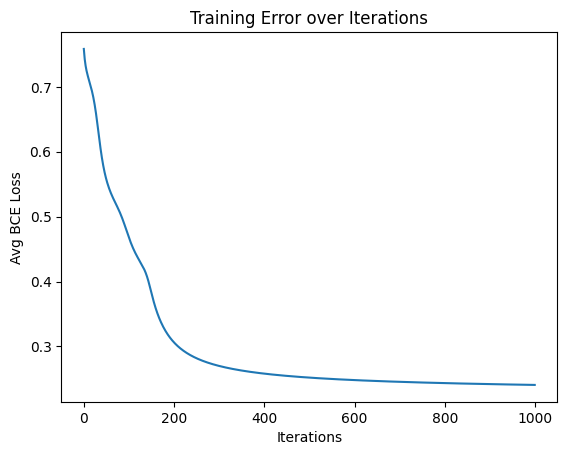

In [283]:


x1 = torch.tensor([0., 0., 1., 1.])
x2 = torch.tensor([0., 1., 0., 1.])

bias = torch.ones_like(x1)
#^ bias added
x = torch.stack([x1, x2, bias]).permute(1, 0) 

print("Input shape:", x.shape)
#^ target outputs
y = torch.tensor([0., 1., 1., 0.])  


lr = 5        
iterations = 1000  
model = NeuralNetwork(num_inputs=3, num_hidden_neurons=2, num_outputs=1)


errors = list()
for ep in range(iterations):
    error = 0.0
    for i in range(x.shape[0]):
        #^ forward
        y_pred = model(x[i])

        loss = bce(y[i], y_pred)
        error += loss.item()
        #^ backward
        model.backward_pass(x[i], y[i], lr)
    # ^avg error
    avg_error = error / x.shape[0]
    errors.append(avg_error)

plt.plot(range(iterations), errors)
plt.xlabel('Iterations')
plt.ylabel('Avg BCE Loss')
plt.title('Training Error over Iterations')
plt.show()


y_pred = torch.zeros_like(y)
for i in range(x.shape[0]):
    y_pred[i] = model(x[i])
# print(x.shape[1])
# print(x.shape[0])
# print(x.shape)


# 4. Multilayer Perceptron on the Iris Dataset


This section uses PyTorch built-in methods to create an MLP classifier for the Iris dataset.


In [284]:
# iris = datasets.load_iris()
# print(iris.DESCR)


# Load the Iris dataset as a DataFrame
iris_db = datasets.load_iris(as_frame=True)


The Iris data is split into training and test sets using a fixed random seed. The features are normalised using statistics calculated from the training set, and all four attributes are used for classification.


In [285]:
from sklearn.model_selection import train_test_split

from sklearn import datasets
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

In [286]:



random_seed = 69

# ^ following week 4
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    iris_db.data,
    iris_db.target,
    test_size=0.2,
    random_state=random_seed,
    stratify=iris_db.target
)


x_train = torch.from_numpy(X_train.values).float()
x_test = torch.from_numpy(X_test.values).float()

y_train = torch.from_numpy(y_train.values).int().reshape(-1, 1)
y_test = torch.from_numpy(y_test.values).int().reshape(-1, 1)

# ^normalize
def norm_set(x: torch.Tensor, mu: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
    norm = (x - mu) / sigma
    return norm

mean = x_train.mean(dim=0)
std = x_train.std(dim=0)

x_train_normalized = norm_set(x_train, mean, std)
x_test_normalized = norm_set(x_test, mean, std)

x_train = x_train_normalized
x_test = x_test_normalized

# ^ print shapes
# print("Training features shape:", x_train.shape)
# print("Training labels shape:", y_train.shape)
# print("Test features shape:", x_test.shape)
# print("Test labels shape:", y_test.shape)



An MLP with one hidden layer is trained using different hidden-layer sizes: 1, 2, 4, 8, 16, and 32 neurons.

The purpose is to compare how model capacity affects training and test performance, and to contrast the neural network results with the earlier logistic regression approach.
